In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


In [2]:
df = pd.read_csv(r"C:\Users\Azeez\Downloads\data.csv", sep=';', encoding='latin1')
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


# EDA

In [3]:
drop_cols = [
    "Group",
    "Diagnosis in ED",
    "Disposition",
    "Chief_complain",      
    "KTAS_RN",
    "KTAS duration_min",
    "Length of stay_min",
    "Error_group",
    "mistriage",
    "Patients number per hour",
    "Saturation",
    "NRS_pain"
]

In [4]:
df = df.drop(columns=drop_cols, errors='ignore')

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [6]:
df.sex = (df.sex == 2).astype(int)

In [7]:
df['bt'] = pd.to_numeric(df['bt'], errors='coerce')
df['rr'] = pd.to_numeric(df['rr'], errors='coerce')
df['sbp'] = pd.to_numeric(df['sbp'], errors='coerce')
df['dbp'] = pd.to_numeric(df['dbp'], errors='coerce')
df['hr'] = pd.to_numeric(df['hr'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [8]:
df['bt'] = df['bt'].fillna(df['bt'].median())
df['rr'] = df['rr'].fillna(df['rr'].median())
df['sbp'] = df['sbp'].fillna(df['sbp'].median())
df['dbp'] = df['dbp'].fillna(df['dbp'].median())
df['hr'] = df['hr'].fillna(df['hr'].median())
df['age'] = df['age'].fillna(df['age'].median())

In [9]:
cat_features = ["sex", "arrival_mode", "injury", "mental", "pain"]
numerical_features = ['age', 'sbp', 'dbp', 'hr', 'rr', 'bt']

df = df.rename(columns={'ktas_expert': 'triage_level'})
label = 'triage_level'

df = df.copy()

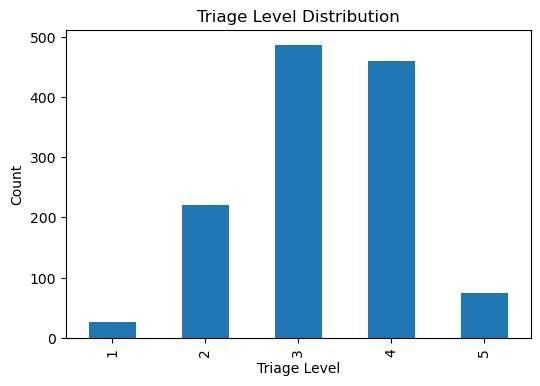

In [10]:
plt.figure(figsize=(6,4))
df[label].value_counts().sort_index().plot(kind="bar")
plt.title("Triage Level Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Count")
plt.show()


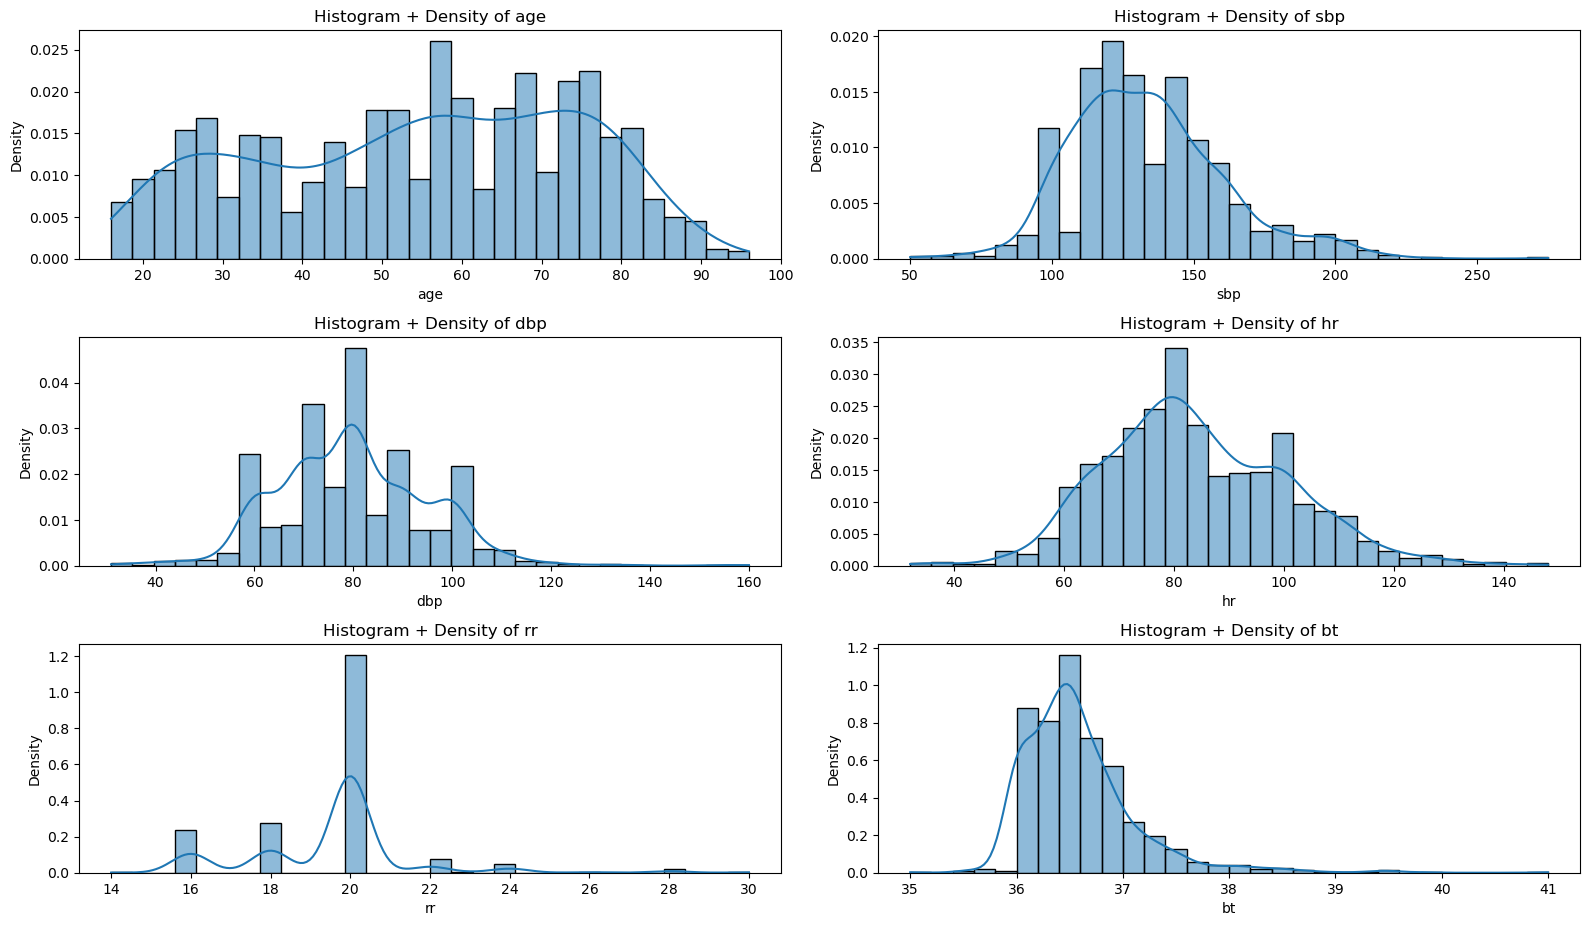

In [11]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        stat='density'
    )
    plt.title(f'Histogram + Density of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [12]:
df[label] = df[label].apply(lambda x: 0 if x <= 3 else 1)

# df[label] = df[label].apply(lambda x: 1 if x <= 3 else 0)


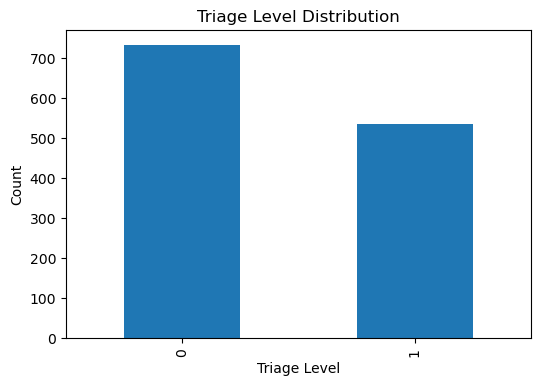

In [13]:
plt.figure(figsize=(6,4))
df[label].value_counts().sort_index().plot(kind="bar")
plt.title("Triage Level Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Count")
plt.show()


In [14]:
encoder = OrdinalEncoder()
df[cat_features] = encoder.fit_transform(df[cat_features])

# Feature Engineering

In [15]:
df['shock_index'] = df['hr'] / df['sbp']         
df['pulse_pressure'] = df['sbp'] - df['dbp']
df['pp_ratio'] = df['pulse_pressure'] / df['sbp']
df['hr_bt_interaction'] = df['hr'] * df['bt']
df['rr_hr_ratio'] = df['rr'] / (df['hr']+1)

# Boolean clinical flags
df['is_fever'] = (df['bt'] >= 38).astype(int)
df['is_tachy'] = (df['hr'] >= 120).astype(int)
df['is_low_sbp'] = (df['sbp'] <= 90).astype(int)
df['is_low_dbp'] = (df['dbp'] <= 60).astype(int)
df['is_tachypnea'] = (df['rr'] >= 22).astype(int)

numerical_features = numerical_features + [
    "shock_index",
    "pulse_pressure",
    "pp_ratio",
    "hr_bt_interaction",
    "rr_hr_ratio"
]

cat_features = cat_features + [
    "is_fever",
    "is_tachy",
    "is_low_sbp",
    "is_low_dbp",
    "is_tachypnea"
]

final_features = (
    cat_features +
    numerical_features
)

# Outlier Handling

In [16]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    return lower, upper, len(outliers)

for col in numerical_features:
    low, high, count = detect_outliers_iqr(df, col)
    print(f"{col}: outliers = {count}, lower={low:.2f}, upper={high:.2f}")


age: outliers = 0, lower=-14.00, upper=122.00
sbp: outliers = 24, lower=62.50, upper=202.50
dbp: outliers = 11, lower=40.00, upper=120.00
hr: outliers = 8, lower=36.00, upper=132.00
rr: outliers = 55, lower=15.00, upper=23.00
bt: outliers = 50, lower=35.30, upper=37.70
shock_index: outliers = 32, lower=0.20, upper=1.07
pulse_pressure: outliers = 39, lower=5.50, upper=97.50
pp_ratio: outliers = 25, lower=0.21, upper=0.59
hr_bt_interaction: outliers = 17, lower=1379.57, upper=4764.57
rr_hr_ratio: outliers = 19, lower=0.11, upper=0.36


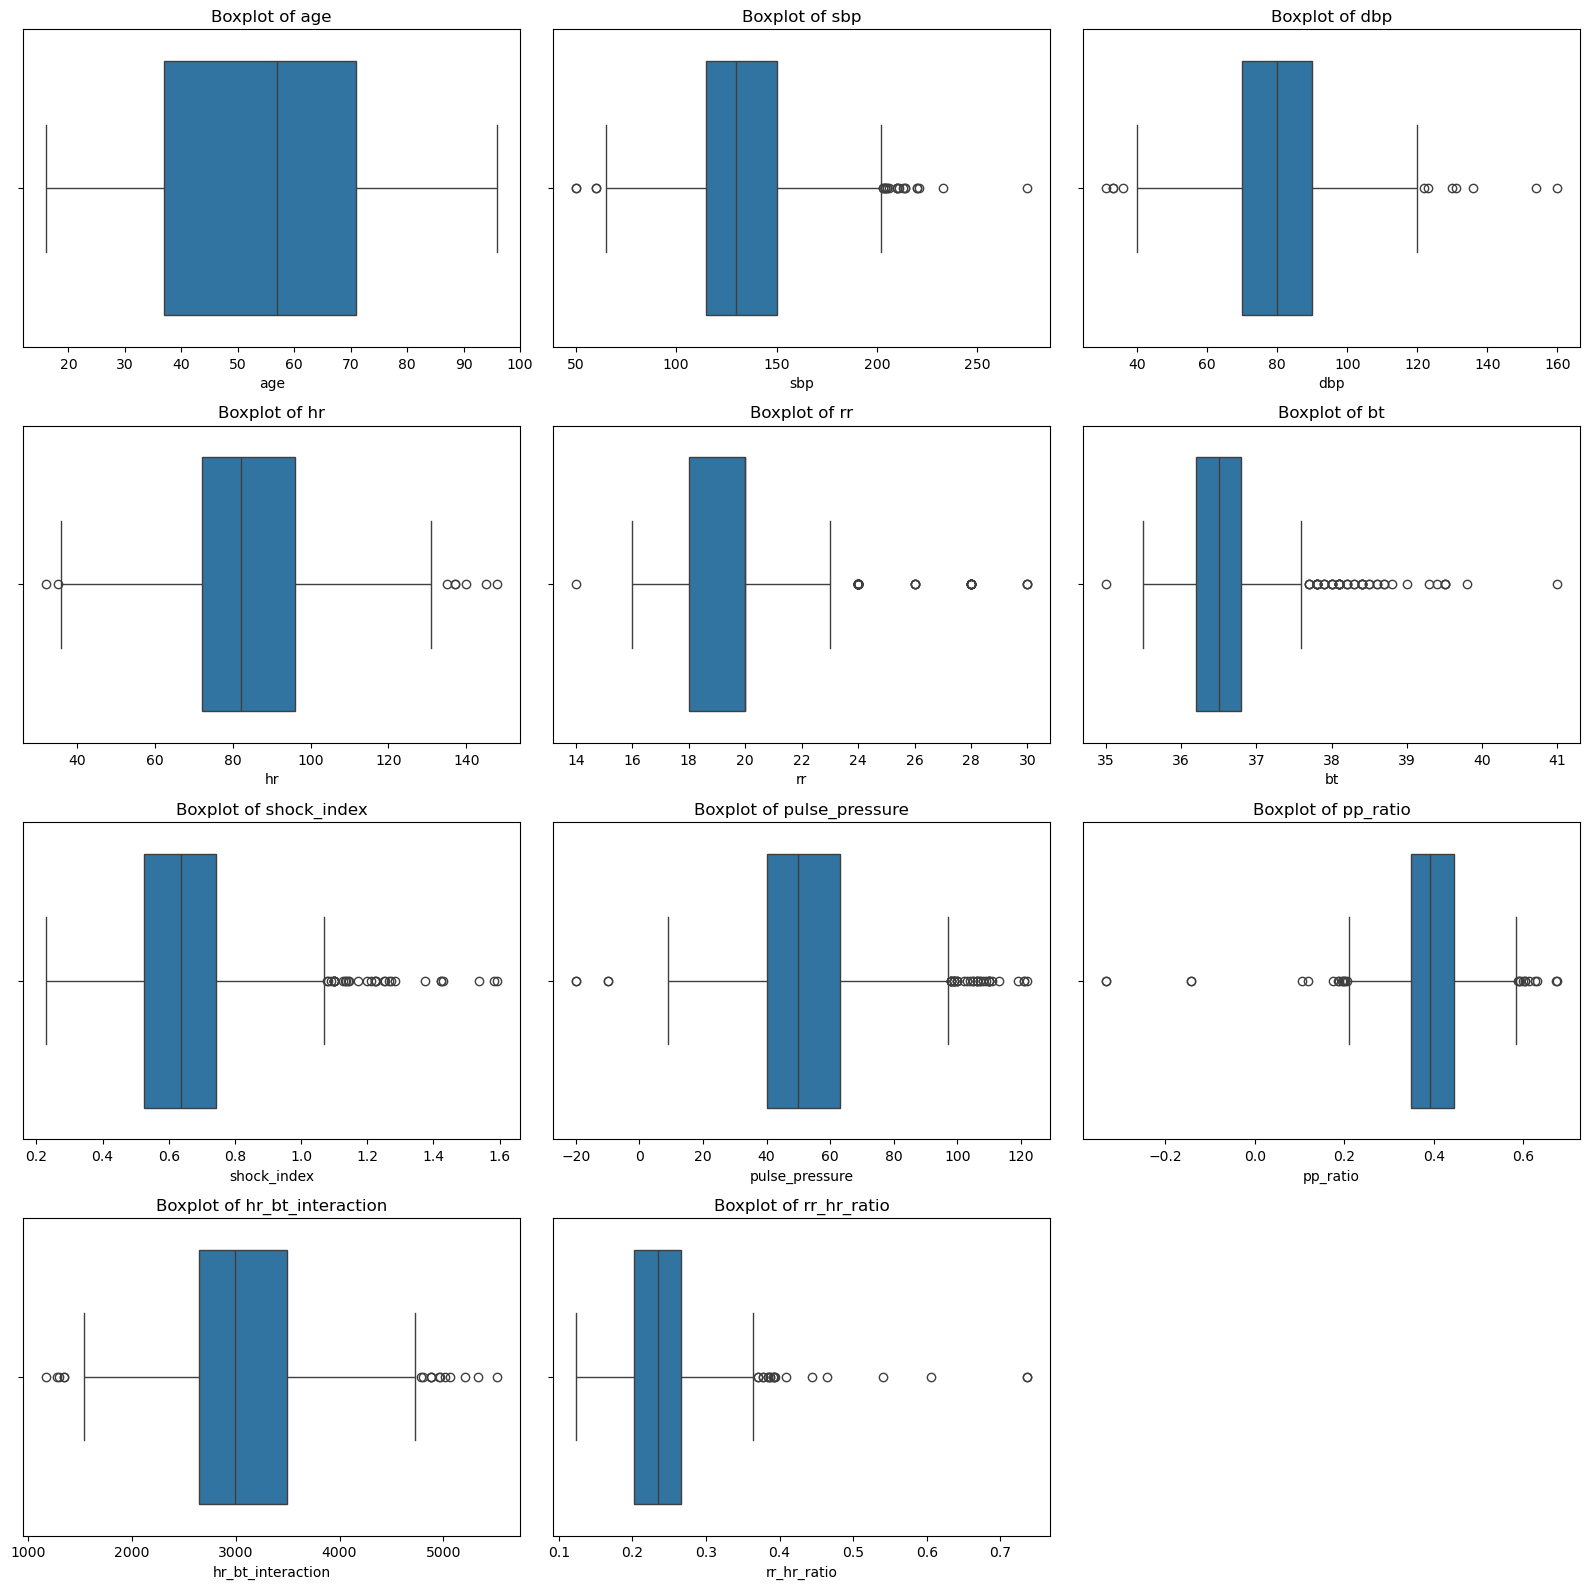

In [17]:
import math

num_cols = len(numerical_features)
rows = math.ceil(num_cols / 3)

plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [18]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped to range [{lower:.2f}, {upper:.2f}]")

for col in numerical_features:
    cap_outliers_iqr(df, col)


age: capped to range [-14.00, 122.00]
sbp: capped to range [62.50, 202.50]
dbp: capped to range [40.00, 120.00]
hr: capped to range [36.00, 132.00]
rr: capped to range [15.00, 23.00]
bt: capped to range [35.30, 37.70]
shock_index: capped to range [0.20, 1.07]
pulse_pressure: capped to range [5.50, 97.50]
pp_ratio: capped to range [0.21, 0.59]
hr_bt_interaction: capped to range [1379.57, 4764.57]
rr_hr_ratio: capped to range [0.11, 0.36]


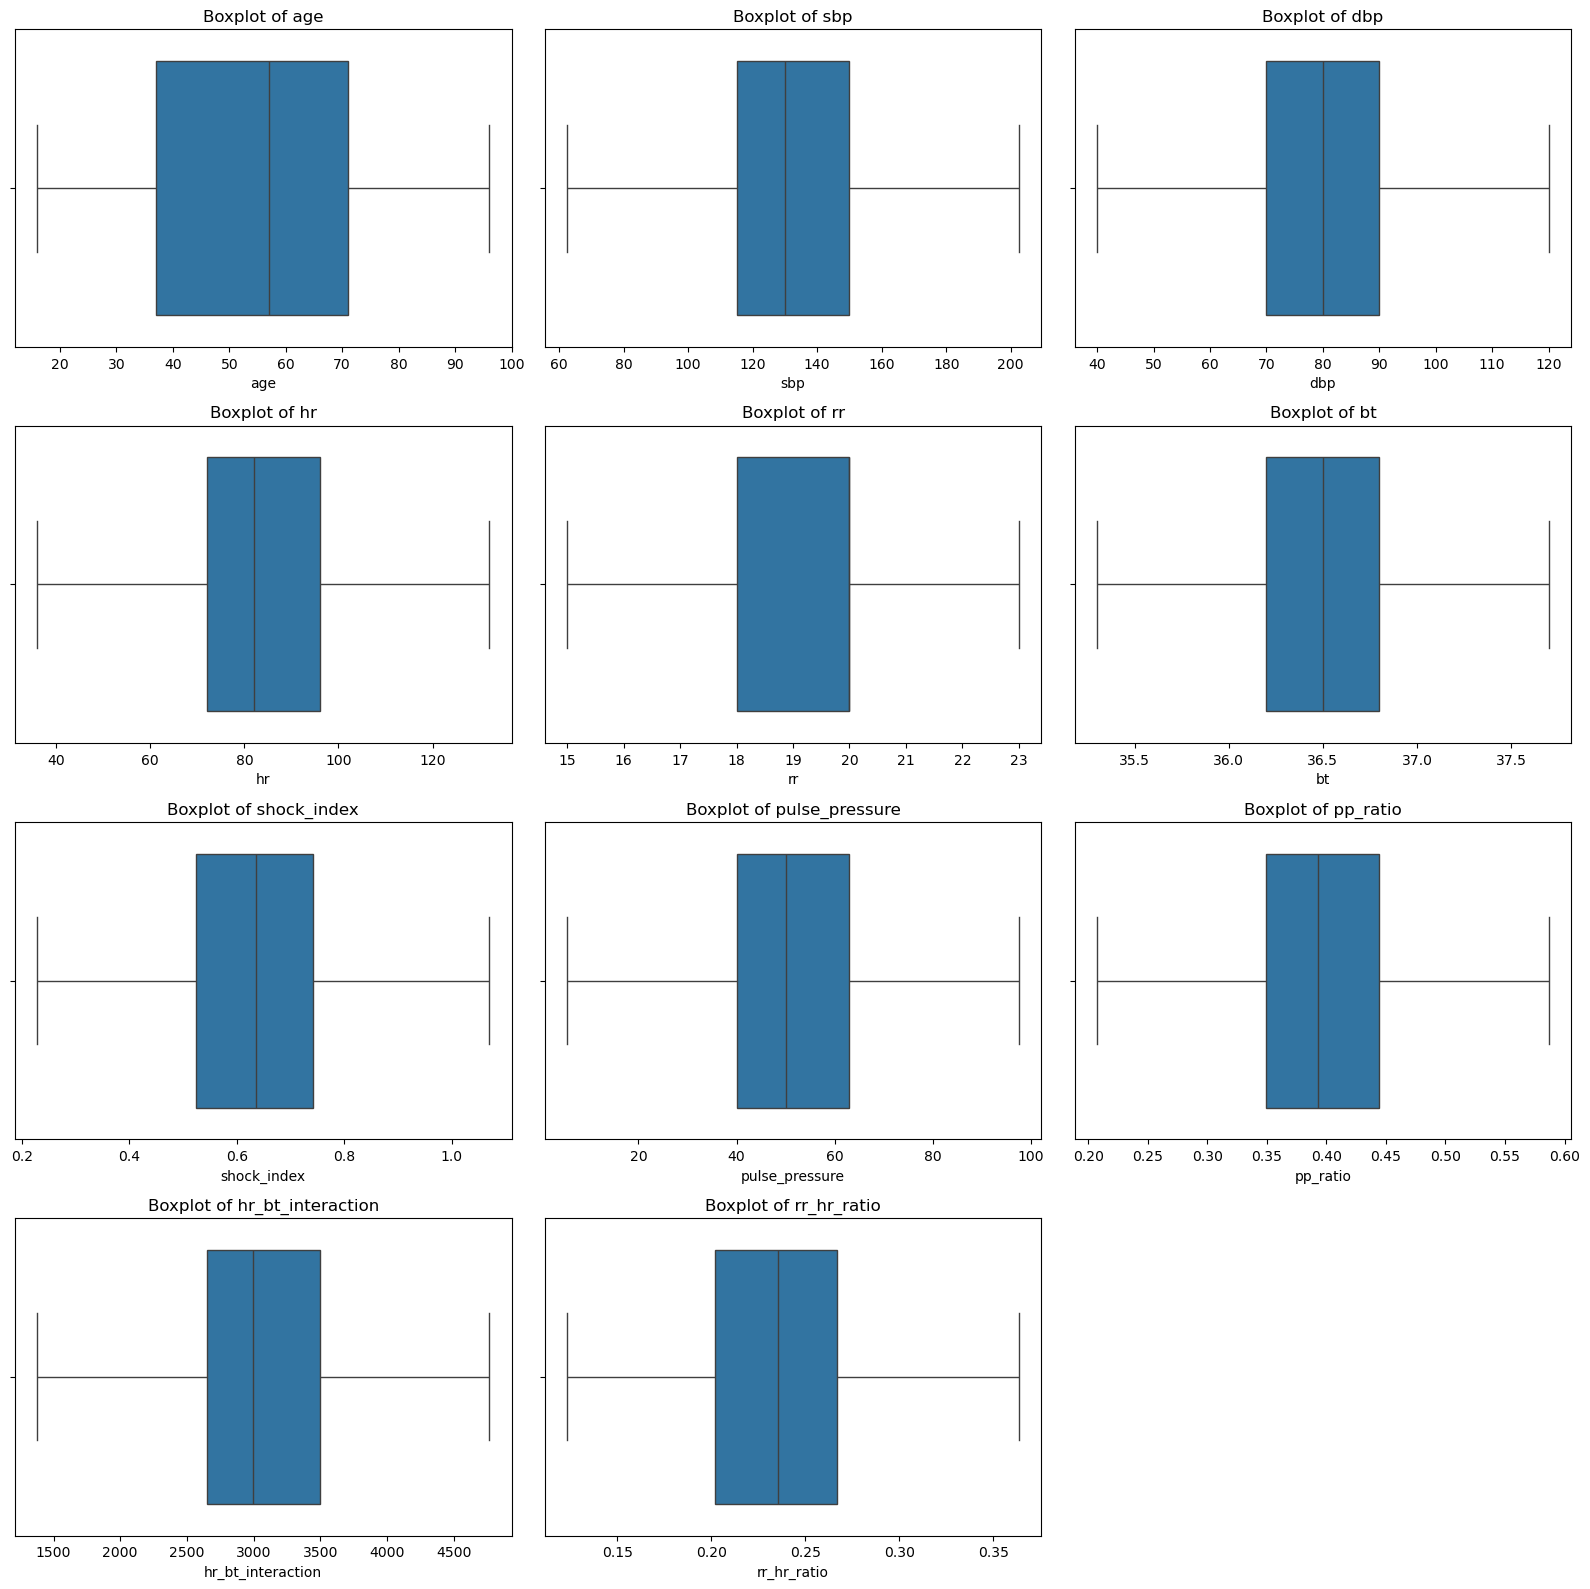

In [19]:
num_cols = len(numerical_features)
rows = math.ceil(num_cols / 3)

plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

# Data Splitting

In [20]:
X = df[final_features]
y = df[label]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [21]:
def calculate_performance(model, X_test):
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print("Accuracy: ", acc*100)
    print("Precision: ", precision*100)
    print("Recall: ", recall*100)
    print("F1: ", f1*100)

# def calculate_performance(model, X_test):
#     predictions = model.predict(X_test)

#     acc = accuracy_score(y_test, predictions)
#     precision = precision_score(y_test, predictions, pos_label=1)  # critical
#     recall = recall_score(y_test, predictions, pos_label=1)
#     f1 = f1_score(y_test, predictions, pos_label=1)

#     print("Accuracy: ", acc * 100)
#     print("Precision: ", precision * 100)
#     print("Recall: ", recall * 100)
#     print("F1 Score: ", f1 * 100)


# XGB Classifier - without feature scalling

In [22]:
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

# Feature Scalling

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # SMOTE: balances class 1 (critical)
# sm = SMOTE(random_state=42)
# X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)



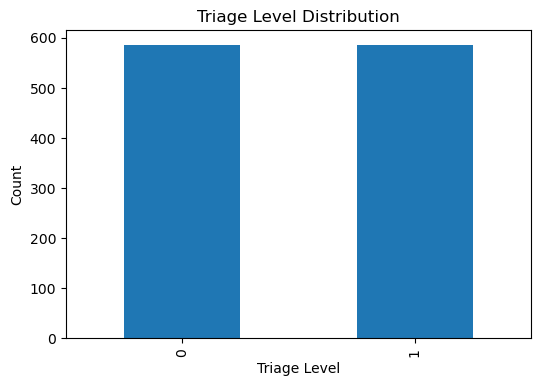

In [24]:
plt.figure(figsize=(6,4))
y_train_smote.value_counts().sort_index().plot(kind="bar")
plt.title("Triage Level Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Count")
plt.show()


# XGB Classifier - with feature scalling

In [25]:
xgb_smote_model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric="logloss"
)

xgb_smote_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

# Random Forest Classifier - with feature scalling

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=45424,
    class_weight="balanced"
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=45424)

In [27]:
# from sklearn.calibration import CalibratedClassifierCV

# calibrated_rf = CalibratedClassifierCV(rf_model, method='isotonic', cv=5)
# calibrated_rf.fit(X_train_smote, y_train_smote)  # Calibrate probabilities


In [28]:
print('-------------XGB--------------')
calculate_performance(xgb_model, X_test)
print('-----------XGB_SMOTE--------------')
calculate_performance(xgb_smote_model, X_test_scaled)
print('------------RF_SMOTE----------')
calculate_performance(rf_model, X_test_scaled)

-------------XGB--------------
Accuracy:  69.29133858267717
Precision:  64.35643564356435
Recall:  60.747663551401864
F1:  62.5
-----------XGB_SMOTE--------------
Accuracy:  72.04724409448819
Precision:  66.98113207547169
Recall:  66.35514018691589
F1:  66.66666666666666
------------RF_SMOTE----------
Accuracy:  74.40944881889764
Precision:  69.44444444444444
Recall:  70.09345794392523
F1:  69.76744186046511


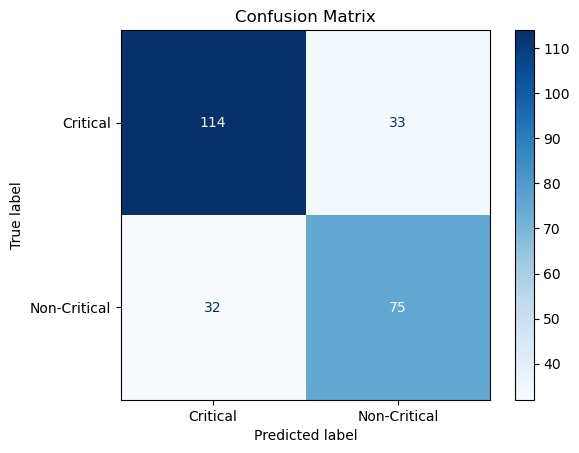

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Critical", "Non-Critical"])
disp.plot(cmap="Blues", values_format="d")

import matplotlib.pyplot as plt
plt.title("Confusion Matrix")
plt.show()


# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Predict on test set
# y_pred = rf_model.predict(X_test_scaled)

# # Compute confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix (Correct label order)
# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm, 
#     display_labels=["Non-Critical", "Critical"]
# )
# disp.plot(cmap="Blues", values_format="d")

# import matplotlib.pyplot as plt
# plt.title("Confusion Matrix")
# plt.show()


In [30]:
cm

array([[114,  33],
       [ 32,  75]])

C:\Users\Azeez\AppData\Local\Temp\ipykernel_20568\2414844680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


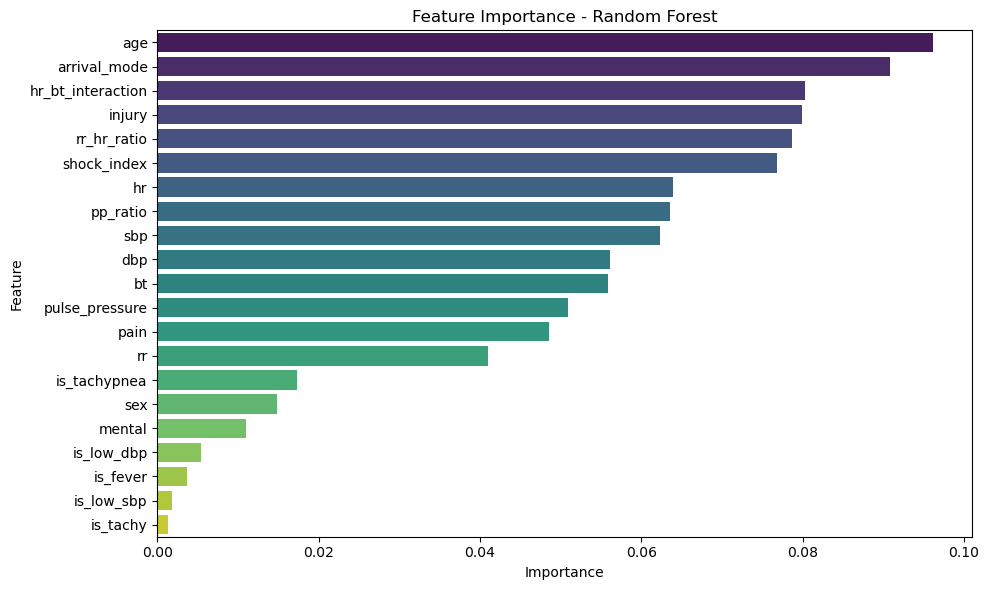

In [31]:
importances = rf_model.feature_importances_
feature_names = final_features  

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

# importances = rf_model.feature_importances_
# feature_names = final_features  

# feat_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(10,6))
# sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
# plt.title("Feature Importance - Random Forest")
# plt.tight_layout()
# plt.show()


In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=cv, scoring='f1')

print("F1 Scores for each fold:", scores)
print("Mean F1 Score:", scores.mean())


# from sklearn.model_selection import cross_val_score, StratifiedKFold

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(
#     rf_model, X_train_smote, y_train_smote, 
#     cv=cv, scoring='f1'
# )

# print("F1 Scores for each fold:", scores)
# print("Mean F1 Score:", scores.mean())


F1 Scores for each fold: [0.75806452 0.72064777 0.67248908 0.76150628 0.73819742]
Mean F1 Score: 0.7301810146842296


In [33]:
# import joblib
#
# joblib.dump(rf_model, "C:/Users/Azeez/Desktop/dir/Campus/Final Project/model/triage_model.pkl")
# joblib.dump(scaler, "C:/Users/Azeez/Desktop/dir/Campus/Final Project/model/scaler.pkl")
# joblib.dump(final_features, "C:/Users/Azeez/Desktop/dir/Campus/Final Project/model/final_features.pkl")


['C:/Users/Azeez/Desktop/dir/Campus/Final Project/model/final_features.pkl']

In [36]:
# inputs = [
#     {"sex":1,"arrival_mode":1,"injury":1,"mental":2,"pain":1,"age":65,"sbp":85,"dbp":50,"hr":135,"rr":24,"bt":39.2},
#     {"sex":0,"arrival_mode":2,"injury":2,"mental":1,"pain":0,"age":28,"sbp":120,"dbp":80,"hr":75,"rr":16,"bt":36.7},
#     {"sex":1,"arrival_mode":3,"injury":2,"mental":1,"pain":0,"age":45,"sbp":110,"dbp":70,"hr":90,"rr":18,"bt":37.0},
#     {"sex":0,"arrival_mode":4,"injury":1,"mental":3,"pain":1,"age":70,"sbp":88,"dbp":55,"hr":125,"rr":23,"bt":38.5},
#     {"sex":1,"arrival_mode":5,"injury":2,"mental":1,"pain":0,"age":32,"sbp":115,"dbp":75,"hr":85,"rr":17,"bt":36.5},
# ]

# df_input = pd.DataFrame(inputs)

# # Derived features
# df_input['shock_index'] = df_input['hr'] / df_input['sbp']
# df_input['pulse_pressure'] = df_input['sbp'] - df_input['dbp']
# df_input['pp_ratio'] = df_input['pulse_pressure'] / df_input['sbp']
# df_input['hr_bt_interaction'] = df_input['hr'] * df_input['bt']
# df_input['rr_hr_ratio'] = df_input['rr'] / (df_input['hr'] + 1)
# df_input['is_fever'] = (df_input['bt'] >= 38).astype(int)
# df_input['is_tachy'] = (df_input['hr'] >= 120).astype(int)
# df_input['is_low_sbp'] = (df_input['sbp'] <= 90).astype(int)
# df_input['is_low_dbp'] = (df_input['dbp'] <= 60).astype(int)
# df_input['is_tachypnea'] = (df_input['rr'] >= 22).astype(int)

# # Select features
# X_input = df_input[final_features]

# # Scale
# X_input_scaled = scaler.transform(X_input)

# # Predict using calibrated RF and rule-based override
# predictions = []
# for i, row in df_input.iterrows():
#     proba = rf_model.predict_proba([X_input_scaled[i]])[0]
#     pred_class = 0 if proba[0] > 0.7 else 1  # threshold
#     # Rule-based override
#     # if row['sbp'] <= 90 or row['hr'] >= 120 or row['rr'] >= 22 or row['bt'] >= 38:
#     #     pred_class = 0
#     predictions.append("Critical" if pred_class == 0 else "Non-Critical")

# df_input['Predicted_Triage'] = predictions
# print(df_input[['sex','arrival_mode','injury','mental','pain','age','sbp','dbp','hr','rr','bt','Predicted_Triage']])

   sex  arrival_mode  injury  mental  pain  age  sbp  dbp   hr  rr    bt  \
0    1             1       1       2     1   65   85   50  135  24  39.2   
1    0             2       2       1     0   28  120   80   75  16  36.7   
2    1             3       2       1     0   45  110   70   90  18  37.0   
3    0             4       1       3     1   70   88   55  125  23  38.5   
4    1             5       2       1     0   32  115   75   85  17  36.5   

  Predicted_Triage  
0         Critical  
1     Non-Critical  
2     Non-Critical  
3         Critical  
4     Non-Critical  


In [35]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
